In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib, json, os, datetime
print("All libraries imported!")

2. Load Data

In [2]:
df = pd.read_csv(r'C:\MyProject\data\train.csv')
print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


3. Explore data

Missing values:
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Target distribution:


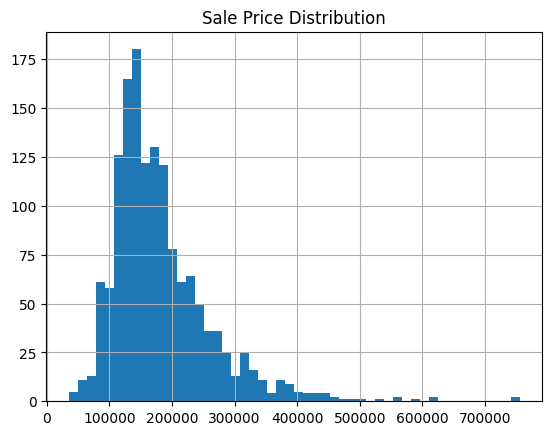

In [3]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget distribution:")
df['SalePrice'].hist(bins=50)
plt.title('Sale Price Distribution')
plt.show()

4. Select & clean features

In [4]:
features = [
    'GrLivArea', 'BedroomAbvGr', 'FullBath',
    'GarageCars', 'TotalBsmtSF', 'YearBuilt',
    'OverallQual', 'Neighborhood', 'SalePrice'
]
df = df[features].copy()
df['TotalBsmtSF'] = df['TotalBsmtSF'].fillna(df['TotalBsmtSF'].median())
df['GarageCars']  = df['GarageCars'].fillna(0)
df['Neighborhood']= df['Neighborhood'].fillna(df['Neighborhood'].mode()[0])
print("Cleaned! Missing values:", df.isnull().sum().sum())

Cleaned! Missing values: 0


5. Feature engineering

In [5]:
current_year   = datetime.datetime.now().year
df['HouseAge'] = current_year - df['YearBuilt']
df = df.drop('YearBuilt', axis=1)
df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)
print("Features ready! Shape:", df.shape)

Features ready! Shape: (1460, 32)


6. Split & scale

In [6]:
X = df.drop('SalePrice', axis=1)
y = np.log1p(df['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1168, 31) Test: (292, 31)


7. Train model

In [7]:
model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    verbosity=0
)
model.fit(X_train_scaled, y_train)

preds = model.predict(X_test_scaled)
actual    = np.expm1(y_test)
predicted = np.expm1(preds)

print(f"R² Score: {r2_score(actual, predicted):.4f}")
print(f"RMSE:     ${np.sqrt(mean_squared_error(actual, predicted)):,.0f}")

R² Score: 0.9026
RMSE:     $27,333


In [ ]:
8. Save model

In [9]:
os.makedirs(r'C:\MyProject\model', exist_ok=True)

joblib.dump(model,  r'C:\MyProject\model\house_price_model.pkl')
joblib.dump(scaler, r'C:\MyProject\model\scaler.pkl')

with open(r'C:\MyProject\model\feature_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

print("Model saved!")


Model saved!
